In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
N_SPLITS = 10  # more folds -> more stable OOF estimate

# ---------------------------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------------------------
print("Loading data...")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


# ---------------------------------------------------------------------------
# 2. Feature Engineering
# ---------------------------------------------------------------------------
def preprocess(df):
    df = df.copy()

    # PassengerId -> Group, Num
    df[["Group", "Num"]] = df["PassengerId"].str.split("_", expand=True)
    df["Group"] = pd.to_numeric(df["Group"])
    df["Num"] = pd.to_numeric(df["Num"])

    # Cabin -> Deck, CabinNum, Side (+ missing flag)
    df["Cabin_missing"] = df["Cabin"].isna().astype(int)
    deck_side = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = deck_side[0]
    df["CabinNum"] = pd.to_numeric(deck_side[1])
    df["Side"] = deck_side[2]
    df["Deck"] = df["Deck"].fillna("Unknown")
    df["Side"] = df["Side"].fillna("Unknown")
    df["CabinNum"] = df["CabinNum"].fillna(df["CabinNum"].median())

    # Amenities: raw, total, zero-spend flag, log transform
    amenities = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["Spend_missing_count"] = df[amenities].isna().sum(axis=1)
    df[amenities] = df[amenities].fillna(0)
    df["TotalSpent"] = df[amenities].sum(axis=1)
    df["ZeroSpent"] = (df["TotalSpent"] == 0).astype(int)
    df["LogTotalSpent"] = np.log1p(df["TotalSpent"])
    for col in amenities:
        df[f"Log_{col}"] = np.log1p(df[col])
        df[f"{col}_ratio"] = df[col] / df["TotalSpent"].replace(0, np.nan)
        df[f"{col}_ratio"] = df[f"{col}_ratio"].fillna(0)

    # Age: missing flag + impute with median, plus age bucket
    df["Age_missing"] = df["Age"].isna().astype(int)
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["IsChild"] = (df["Age"] < 13).astype(int)

    # CryoSleep passengers should have ~0 spend; use this to sanity-fix / flag
    df["CryoSleep_missing"] = df["CryoSleep"].isna().astype(int)
    df["CryoSleep"] = df["CryoSleep"].fillna(df["TotalSpent"] == 0)
    df["CryoSleep"] = df["CryoSleep"].astype(int)

    df["VIP_missing"] = df["VIP"].isna().astype(int)
    df["VIP"] = df["VIP"].fillna(False).astype(int)

    df["HomePlanet"] = df["HomePlanet"].fillna("Unknown")
    df["Destination"] = df["Destination"].fillna("Unknown")

    # Drop columns not modeled directly (keep PassengerId for submission/group calc)
    df = df.drop(columns=["Name", "Cabin"])

    return df


print("Preprocessing datasets...")
train_processed = preprocess(train_df)
test_processed = preprocess(test_df)

# Group size / solo traveler computed across combined Group ids
combined_groups = pd.concat(
    [train_processed[["PassengerId", "Group"]], test_processed[["PassengerId", "Group"]]]
)
group_sizes = combined_groups.groupby("Group")["PassengerId"].transform("count")
combined_groups["GroupSize"] = group_sizes
train_processed = train_processed.merge(
    combined_groups[["PassengerId", "GroupSize"]], on="PassengerId", how="left"
)
test_processed = test_processed.merge(
    combined_groups[["PassengerId", "GroupSize"]], on="PassengerId", how="left"
)
train_processed["IsSolo"] = (train_processed["GroupSize"] == 1).astype(int)
test_processed["IsSolo"] = (test_processed["GroupSize"] == 1).astype(int)

# Now drop PassengerId (kept test_df["PassengerId"] separately for submission)
train_processed = train_processed.drop(columns=["PassengerId"])
test_ids = test_df["PassengerId"]
test_processed = test_processed.drop(columns=["PassengerId"])

# Encode categoricals consistently, keep as pandas 'category' dtype for native handling
categorical_cols = ["HomePlanet", "Destination", "Deck", "Side"]
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat(
        [train_processed[col].astype(str), test_processed[col].astype(str)]
    )
    le.fit(combined)
    train_processed[col] = le.transform(train_processed[col].astype(str))
    test_processed[col] = le.transform(test_processed[col].astype(str))
    train_processed[col] = train_processed[col].astype("category")
    test_processed[col] = test_processed[col].astype("category")

X = train_processed.drop(columns=["Transported"])
y = train_processed["Transported"].astype(int)
X_test = test_processed

print(f"Final feature count: {X.shape[1]}")

# ---------------------------------------------------------------------------
# 3. Out-of-fold training for LightGBM + XGBoost, stratified CV
# ---------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

print(f"\nRunning {N_SPLITS}-Fold Stratified CV with LightGBM + XGBoost...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # LightGBM (native categorical handling)
    lgb_model = lgb.LGBMClassifier(
        n_estimators=600,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=6,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=RANDOM_STATE,
        verbose=-1,
    )
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=categorical_cols,
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_lgb += lgb_model.predict_proba(X_test)[:, 1] / N_SPLITS

    # XGBoost (needs numeric categoricals -> use int codes)
    X_tr_xgb = X_tr.copy()
    X_val_xgb = X_val.copy()
    X_test_xgb = X_test.copy()
    for c in categorical_cols:
        X_tr_xgb[c] = X_tr_xgb[c].astype(int)
        X_val_xgb[c] = X_val_xgb[c].astype(int)
        X_test_xgb[c] = X_test_xgb[c].astype(int)

    xgb_model = xgb.XGBClassifier(
        n_estimators=600,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        early_stopping_rounds=50,
        verbosity=0,
    )
    xgb_model.fit(X_tr_xgb, y_tr, eval_set=[(X_val_xgb, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val_xgb)[:, 1]
    test_xgb += xgb_model.predict_proba(X_test_xgb)[:, 1] / N_SPLITS

    fold_acc = accuracy_score(
        y_val, ((oof_lgb[val_idx] + oof_xgb[val_idx]) / 2 > 0.5)
    )
    print(f"Fold {fold + 1}/{N_SPLITS} blended accuracy: {fold_acc:.4f}")

# ---------------------------------------------------------------------------
# 4. Blend and evaluate OOF performance (this is your real, unbiased accuracy)
# ---------------------------------------------------------------------------
oof_blend = (oof_lgb + oof_xgb) / 2
test_blend = (test_lgb + test_xgb) / 2

blend_preds = (oof_blend > 0.5).astype(int)

print("\n" + "=" * 50)
print("OUT-OF-FOLD (unbiased) PERFORMANCE — BLENDED MODEL")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y, blend_preds):.4f}")
print(f"Precision : {precision_score(y, blend_preds):.4f}")
print(f"Recall    : {recall_score(y, blend_preds):.4f}")
print(f"F1 score  : {f1_score(y, blend_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y, oof_blend):.4f}")
print(f"Log loss  : {log_loss(y, oof_blend):.4f}")
print("=" * 50)

for name, oof in [("LightGBM", oof_lgb), ("XGBoost", oof_xgb)]:
    acc = accuracy_score(y, (oof > 0.5).astype(int))
    print(f"{name} solo OOF accuracy: {acc:.4f}")

# ---------------------------------------------------------------------------
# 5. Generate Kaggle Submission File (using averaged test predictions)
# ---------------------------------------------------------------------------
print("\nGenerating submission.csv...")
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": (test_blend > 0.5),
})
submission.to_csv("submission.csv", index=False)
print("submission.csv successfully created!")

Loading data...
Preprocessing datasets...


/tmp/ipykernel_1436/3748617262.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["CryoSleep"] = df["CryoSleep"].fillna(df["TotalSpent"] == 0)
/tmp/ipykernel_1436/3748617262.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["VIP"] = df["VIP"].fillna(False).astype(int)
/tmp/ipykernel_1436/3748617262.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent

Final feature count: 36

Running 10-Fold Stratified CV with LightGBM + XGBoost...
Fold 1/10 blended accuracy: 0.7977
Fold 2/10 blended accuracy: 0.8253
Fold 3/10 blended accuracy: 0.8230
Fold 4/10 blended accuracy: 0.7975
Fold 5/10 blended accuracy: 0.8216
Fold 6/10 blended accuracy: 0.8136
Fold 7/10 blended accuracy: 0.8228
Fold 8/10 blended accuracy: 0.8101
Fold 9/10 blended accuracy: 0.8147
Fold 10/10 blended accuracy: 0.7998

OUT-OF-FOLD (unbiased) PERFORMANCE — BLENDED MODEL
Accuracy  : 0.8126
Precision : 0.8127
Recall    : 0.8159
F1 score  : 0.8143
ROC-AUC   : 0.9043
Log loss  : 0.3812
LightGBM solo OOF accuracy: 0.8139
XGBoost solo OOF accuracy: 0.8105

Generating submission.csv...
submission.csv successfully created!


### Feature Importance Analysis

Let's examine which features the LightGBM model considered most important.

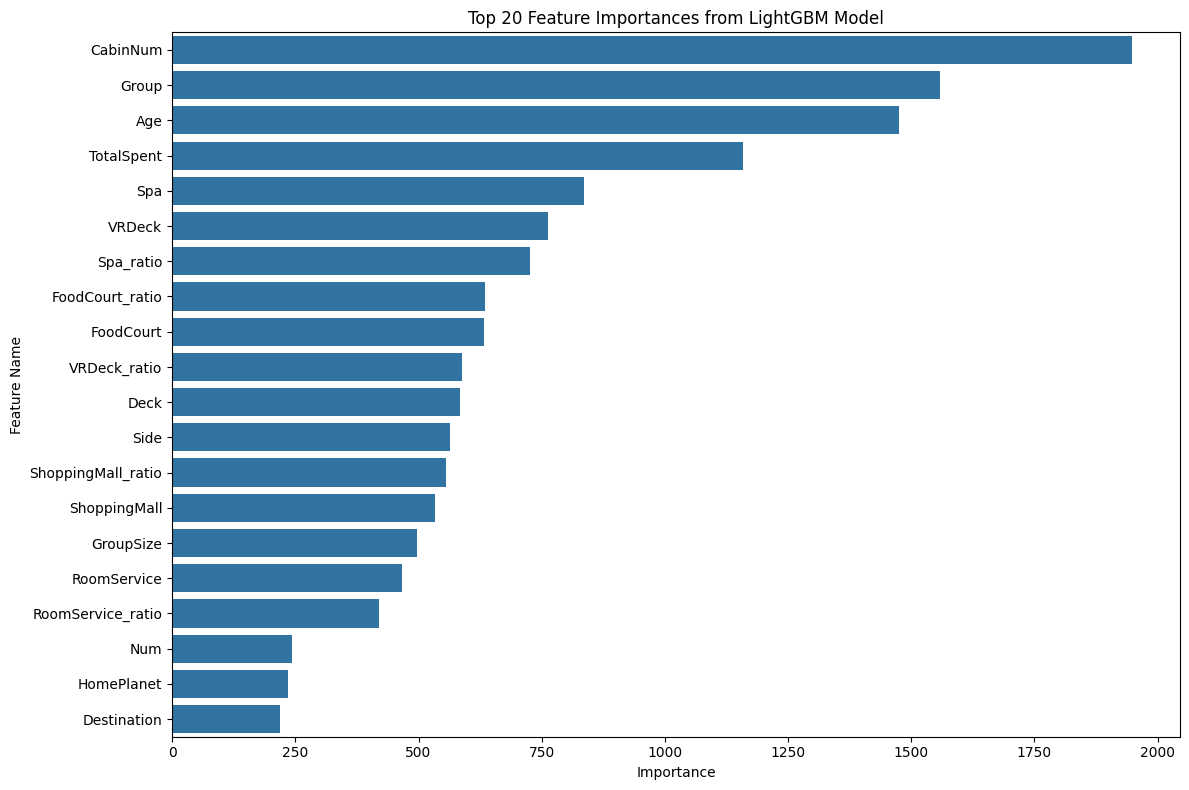

,Feature,Importance
14,CabinNum,1948
10,Group,1559
3,Age,1476
17,TotalSpent,1159
8,Spa,835
9,VRDeck,762
27,Spa_ratio,726
23,FoodCourt_ratio,635
6,FoodCourt,632
29,VRDeck_ratio,589


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained final_model
feature_importances = final_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top 20 features for clarity
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

display(importance_df.head(10))